#### langchain Version V1

In [1]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/biman_giri/Documents/OfficeWork/MyDay2DayLearning/.env")
openai_token = os.getenv("OPENAI_API_TOKEN")
openai_base_url = os.getenv("OPENAI_API_BASE")
lanchain_endpoint = os.getenv("LANGSMITH_ENDPOINT")
lanchain_api_key = os.getenv("LANGSMITH_API_KEY")
lanchain_project = os.getenv("LANGSMITH_PROJECT")
lanchain_tracing_v2 = os.getenv("LANGSMITH_TRACING")

In [3]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(model="gpt-4o", api_key=openai_token, base_url=openai_base_url)
# define output parser
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    """
You are a helpful assistant, answer the question based on your knowledge.

Question: {question}

Answer:
"""
)
chain = prompt | llm_model | StrOutputParser()

result = chain.invoke({"question": "What is the capital of France?"})
print(result)

/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The capital of France is Paris.


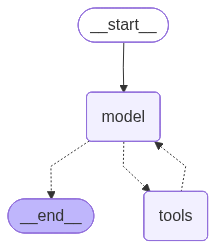

In [4]:
from langchain.agents import create_agent


def get_weather(city: str) -> str:
    """Get the weather in a given city"""
    return f"The weather in {city} is sunny"


agent = create_agent(
    model=llm_model, tools=[get_weather], system_prompt="You are a helpful assistant"
)
agent

In [5]:
# run the agent
from langchain_core.messages import HumanMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="What is the weather in Tokyo?")]}
)
response["messages"][-1].content

'The weather in Tokyo is sunny.'

In [6]:
response = agent.invoke(
    {"messages": {"role": "user", "content": "What is the weather in Tokyo?"}}
)
response["messages"][-1].content

'The weather in Tokyo is sunny.'

In [7]:
response = agent.invoke({"messages": "what is the weather in Tokyo?"})
response["messages"][-1].content

'The weather in Tokyo is currently sunny.'

In [8]:
llm_model.invoke("write me a 200 words paragraph on Artificial Intelligence")

AIMessage(content="Artificial Intelligence (AI) is revolutionizing various aspects of modern life, encompassing sectors from healthcare to finance, and transforming them with unprecedented efficiency and innovation. At its core, AI involves creating systems capable of performing tasks that traditionally require human intelligence. These tasks include learning, reasoning, problem-solving, perception, and natural language understanding. By leveraging vast amounts of data and complex algorithms, AI systems can identify patterns, make decisions, and even predict future events with remarkable accuracy. In healthcare, AI aids in diagnosing diseases, personalizing treatments, and managing patient care more effectively. Financial institutions employ AI for fraud detection, risk management, and automating routine transactions, thereby enhancing security and operational efficiency. AI-powered chatbots and virtual assistants are becoming increasingly sophisticated, providing customer service and 

In [9]:
for chunk in llm_model.stream(
    "write a paragraph of 200 words on Artificial Intelligence"
):
    print(chunk.text, end="", flush=True)

Artificial Intelligence (AI), a branch of computer science, is revolutionizing various sectors by creating systems capable of performing tasks that would typically require human intelligence. These tasks include understanding natural language, recognizing patterns and images, making decisions, and learning from data. AI technologies, such as machine learning and deep learning, have seen significant advancements, enabling machines to analyze vast amounts of data with unparalleled speed and accuracy. This evolution is driven by the convergence of big data, improved algorithms, and powerful computing capacities, enabling machines to mimic and even surpass certain human cognitive abilities. AI is transforming industries such as healthcare, where it aids in diagnosing diseases and personalizing treatments, and in finance, where it streamlines operations, enhances security, and enriches customer experiences. In transportation, AI is integral to the development of autonomous vehicles that pro

In [10]:
responses = llm_model.batch(
    [
        "write me a 200 words paragraph on Artificial Intelligence",
        "write me a 200 words paragraph on Machine Learning",
    ]
)
for response in responses:
    print(response.content)

Artificial Intelligence (AI) represents a transformative force in the modern world, reshaping industries, enhancing efficiencies, and pioneering new realms of human-machine collaboration. As algorithms become increasingly sophisticated, AI systems are adept at processing vast datasets with unprecedented speed and accuracy, uncovering patterns and insights that were previously inaccessible to human analysts. In healthcare, AI enhances diagnostic accuracy through predictive analytics and personalized medicine, promising a future where treatments are tailored to individual genetic blueprints. Meanwhile, in the realm of autonomous vehicles, AI is steering a revolution towards safer, more efficient transport systems. Businesses are leveraging AI for more than just productivity gains; it's driving innovation in customer service through chatbots and virtual assistants, offering personalized experiences at scale. However, the rise of AI also invokes critical discussions around ethics, privacy,

In [11]:
responses = llm_model.batch(
    [
        "write me a 200 words paragraph on Artificial Intelligence",
        "write me a 200 words paragraph on Machine Learning",
    ],
    config={"max_concurrency": 3},
)
for response in responses:
    print(response.content)

Artificial Intelligence (AI) represents one of the most transformative technological advancements of the 21st century, influencing a wide array of fields such as healthcare, finance, transportation, and entertainment. At its core, AI involves the development of computer systems capable of performing tasks that typically require human intelligence, such as decision-making, problem-solving, and language understanding. Machine learning, a subset of AI, enables systems to learn from vast datasets and improve their performance over time without being explicitly programmed. This ability to analyze and interpret complex patterns allows AI to automate processes, enhance operational efficiency, and foster innovation. In healthcare, AI aids in the early detection of diseases through image analysis, while in finance, it optimizes trading strategies and manages risks. Autonomous vehicles are revolutionizing transportation with AI-driven navigation systems, significantly reducing human error. Moreo

In [12]:
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """Get the weather of a given city"""
    return f"The weather of {city} is sunny"


model_with_weather_tools = llm_model.bind_tools([get_weather])

In [13]:
response = model_with_weather_tools.invoke("What is the weather in Tokyo?")

print(response)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 52, 'total_tokens': 66, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cb0ea620e7', 'id': 'chatcmpl-DKOlZmskXPin94W3ippsi3Sb2oeqV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cfbfc-28e8-7581-a4f0-6a578cc413e4-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'call_m3KbCRntFCcq9vlTFXycl9cv', 'type': 'tool_call'}] usage_metadata={'input_tokens': 52, 'output_tokens': 14, 'total_tokens': 66, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [14]:
for tool_call in response.tool_calls:
    print("Tool: ", tool_call["name"])
    print("Args: ", tool_call["args"])

Tool:  get_weather
Args:  {'city': 'Tokyo'}


In [15]:
# the message from the LLM is a AIMessage and when user get the response, it is a HumanMessage
llm_model.invoke("what is artificial intelligence?")

AIMessage(content='Artificial intelligence (AI) refers to the development of computer systems that can perform tasks typically requiring human intelligence. These tasks include reasoning, learning, problem-solving, perception, understanding natural language, and even motor functions. AI can be divided into several categories based on complexity and application:\n\n1. **Narrow AI** (or Weak AI): This type of AI is designed to handle a narrow set of tasks. Examples include virtual assistants like Siri or Alexa, recommendation algorithms used by streaming services, and image recognition systems.\n\n2. **General AI** (or Strong AI): This is a theoretical form of AI that possesses the ability to understand, learn, and apply intelligence at a human level across a wide range of tasks. Strong AI remains largely aspirational, as it aims to achieve consciousness and general cognitive abilities akin to a human brain.\n\n3. **Superintelligent AI**: A hypothetical AI that surpasses human intelligen

### Message prompt
Here are different message types 
- SystemMessage : Tells the model , how it should behave.
- HumanMessage : Represent user input and interaction with the model.
- AIMessage : reponse generated by the model, including text context, tool calls and metadata.
- ToolMessage : Represents the output of the tool message.

In [16]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

message = [
    SystemMessage(content="You are a poetry expert"),
    HumanMessage(content="write a poem about a cat"),
]

response = llm_model.invoke(message)
response.content

"In twilight glow of evening's grace,  \nA silhouette begins its dance,  \nUpon the fence, a feline trace,  \nA master of the moonlit prance.  \n\nIn velvet fur, the shadows cling,  \nIts eyes two orbs of ancient gold,  \nSecrets of the night they bring,  \nA story silent, yet untold.  \n\nWith whisper-soft on padded feet,  \nIt stalks the alley’s whispered song,  \nAnd where the quiet heartbeats meet,  \nThe night seems neither weak nor strong.  \n\nThrough starry meadows, paws do roam,  \nA poet in a land of dreams,  \nThe night, this velvet wanderer's home,  \nA world alight with gentle schemes.  \n\nAmong the milky stars it weaves,  \nIts kingdom vast and free of time,  \nWhere every leap and twist perceives,  \nThe artful splendor in its climb.  \n\nOh graceful spirit, prowler wise,  \nYou navigate the shadow's deep,  \nA sage that wears a midnight guise,  \nWho dreams while others are asleep.  "

In [17]:
system_msg = SystemMessage(content="you are helpful coding assistant")
message = [
    system_msg,
    HumanMessage(content="how to implement binary search tree in python?"),
]
response = llm_model.invoke(message)
print(response.content)

Implementing a Binary Search Tree (BST) in Python involves creating a class for the nodes in the tree and a class for the tree itself. Each node in a BST has a key, and possibly left and right children, where the left child's key is less than its own key, and the right child's key is greater.

Here's a simple implementation of a Binary Search Tree in Python:

```python
class Node:
    def __init__(self, key):
        self.left = None
        self.right = None
        self.val = key


class BinarySearchTree:
    def __init__(self):
        self.root = None

    def insert(self, key):
        if self.root is None:
            self.root = Node(key)
        else:
            self._insert_recursively(self.root, key)

    def _insert_recursively(self, node, key):
        if key < node.val:
            if node.left is None:
                node.left = Node(key)
            else:
                self._insert_recursively(node.left, key)
        else:
            if node.right is None:
         

In [18]:
### detailed information to the LLM through system message
from langchain.messages import SystemMessage, HumanMessage

system_message = SystemMessage(
    content=""" you are senior python develop with expertiese in web fraemwroks.
Always provide code examples and explain your resoning. 
Be consise but through in your explanations.
"""
)
messages = [
    system_message,
    HumanMessage("how to implement binary search tree in python?"),
]
response = llm_model.invoke(messages)
print(response.content)

To implement a Binary Search Tree (BST) in Python, you'll need to define a class for the tree node and the tree itself. Here's a simple and classic implementation:

1. **Define the Node Class**: This class represents each node in the BST. Each node has a key (or value) and pointers to its left and right children.

2. **Define the BST Class**: This class will handle the operations on the BST, such as insertion, search, and traversal.

### 1. Node Class

```python
class Node:
    def __init__(self, key):
        self.left = None
        self.right = None
        self.val = key
```

### 2. BST Class

```python
class BinarySearchTree:
    def __init__(self):
        self.root = None

    def insert(self, key):
        if self.root is None:
            self.root = Node(key)
        else:
            self._insert_recursively(self.root, key)

    def _insert_recursively(self, current_node, key):
        if key < current_node.val:
            if current_node.left is None:
                curre

In [19]:
human_msg = HumanMessage(content="Hello", name="Biman", id="123")
llm_model.invoke([human_msg])

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 10, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_4658d56e13', 'id': 'chatcmpl-DKOm4USKNzbHrQLhAgt0oVUTMaKAI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfbfc-a304-7541-bd82-1f4000da781c-0', usage_metadata={'input_tokens': 10, 'output_tokens': 9, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [20]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

ai_msg = AIMessage("I would be happy to help you with that question")
message = [
    SystemMessage("you are helpful assistant"),
    HumanMessage("can you help me ?"),
    ai_msg,
    HumanMessage("Great! what is 2 + 2"),
]
response = llm_model.invoke(message)
print(response.content)

2 + 2 equals 4.


In [21]:
response.usage_metadata

{'input_tokens': 47,
 'output_tokens': 8,
 'total_tokens': 55,
 'input_token_details': {'audio': 0, 'cache_read': 0},
 'output_token_details': {'audio': 0, 'reasoning': 0}}

In [ ]:
from langchain.messages import AIMessage
from langchain.messages import HumanMessage

ai_message = AIMessage(
    content=[],
    tool_calls=[
        {"name": "get_weather", "args": {"location": "San Francisco"}, "id": "call_123"}
    ],
)

weather_result = "Sunny, 72F"
tool_message = ToolMessage(
    content=weather_result, name="get_weather", tool_call_id="call_123"
)
messages = [
    HumanMessage("Waht is the weather in San Francisco?"),
    ai_message,
    tool_message,
]
response = llm_model.invoke(messages)
print(response.content)

The weather in San Francisco is currently sunny with a temperature of 72°F.


#### Structured Output
Modes can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output. 

## Pydantic

In [ ]:
from pydantic import BaseModel, Field


class Movie(BaseModel):
    title: str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director: str = Field(description="The director of the movie")
    rating: float = Field(
        description="rating of the movie according the data that you have"
    )


model_with_structured_output = llm_model.with_structured_output(Movie)

model_with_structured_output

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x116194150>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11738e510>, root_client=<openai.OpenAI object at 0x1160d50d0>, root_async_client=<openai.AsyncOpenAI object at 0x11738e150>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openai.prod.ai-gateway.quantumblack.com/9e4ef1b4-769a-496f-8304-a84d63270e0d/v1'), kwargs={'response_format': <class '__main__.Movie'>, 'ls_structured_output

In [ ]:
response = model_with_structured_output.invoke(
    "provide the details of the movie Inception"
)

In [ ]:
#### Message output and paresed structured

from pydantic import BaseModel, Field


class Movie(BaseModel):
    title: str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director: str = Field(description="The director of the movie")
    rating: float = Field(
        description="rating of the movie according the data that you have"
    )


model_with_structure = llm_model.with_structured_output(Movie, include_raw=True)
response = model_with_structure.invoke("provide the details of the movie Inception")
response

{'raw': AIMessage(content='{"title":"Inception","year":2010,"director":"Christopher Nolan","rating":8.8}', additional_kwargs={'parsed': Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8), 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 122, 'total_tokens': 144, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7c4b976237', 'id': 'chatcmpl-DKP717o2IPpnwkEgUIEAUEuGptJVY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfc10-75bb-7791-9433-23654c08fd82-0', usage_metadata={'input_tokens': 122, 'output_tokens': 22, 'total_tokens': 144, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0

#### Nested structure

In [ ]:
from pydantic import BaseModel, Field


class Actor(BaseModel):
    name: str = Field(description="the name of the actor")
    age: int = Field(description="the age of the actor")
    nationality: str = Field(description="the nationality of the actor")


class Movie(BaseModel):
    title: str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director: str = Field(description="The director of the movie")
    rating: float = Field(
        description="rating of the movie according the data that you have"
    )
    actors: list[Actor] = Field(description="list of actors in the movie")


model_with_nested_structure = llm_model.with_structured_output(Movie, include_raw=True)
response = model_with_nested_structure.invoke(
    "provide the details of the movie Inception"
)
print(response)

{'raw': AIMessage(content='{"title":"Inception","year":2010,"director":"Christopher Nolan","rating":8.8,"actors":[{"name":"Leonardo DiCaprio","age":38,"nationality":"American"},{"name":"Joseph Gordon-Levitt","age":32,"nationality":"American"},{"name":"Elliot Page","age":26,"nationality":"Canadian"},{"name":"Tom Hardy","age":33,"nationality":"British"}]}', additional_kwargs={'parsed': Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8, actors=[Actor(name='Leonardo DiCaprio', age=38, nationality='American'), Actor(name='Joseph Gordon-Levitt', age=32, nationality='American'), Actor(name='Elliot Page', age=26, nationality='Canadian'), Actor(name='Tom Hardy', age=33, nationality='British')]), 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 228, 'total_tokens': 318, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_de

/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Movie(title='Inception', ...nationality='British')]), input_type=Movie])
  return self.__pydantic_serializer__.to_python(


## TypedDict

In [ ]:
from typing import TypedDict, Annotated


class Movie(TypedDict):
    """the movie with details"""

    title: Annotated[str, "The title of the moview"]
    year: Annotated[int, "The year the movie was released"]
    director: Annotated[str, "The director of the movie"]
    rating: Annotated[float, "rating of the movie according the data that you have"]


model_with_typed_dict = llm_model.with_structured_output(Movie)
response = model_with_typed_dict.invoke("provide the details of the movie Inception")
print(response)

{'title': 'Inception', 'year': 2010, 'director': 'Christopher Nolan', 'rating': 8.8}


In [ ]:
from typing import TypedDict, Annotated


class Actor(TypedDict):
    """the actor with details"""

    name: Annotated[str, "the name of the actor"]
    age: Annotated[int, "the age of the actor"]
    nationality: Annotated[str, "the nationality of the actor"]


class Movie(TypedDict):
    """the movie with details"""

    title: Annotated[str, "The title of the moview"]
    year: Annotated[int, "The year the movie was released"]
    director: Annotated[str, "The director of the movie"]
    rating: Annotated[float, "rating of the movie according the data that you have"]
    actors: Annotated[list[Actor], "list of actors in the movie"]


model_with_typed_dict = llm_model.with_structured_output(Movie)
response = model_with_typed_dict.invoke("provide the details of the movie Inception")
print(response)

{'title': 'Inception', 'year': 2010, 'director': 'Christopher Nolan', 'rating': 8.8, 'actors': [{'name': 'Leonardo DiCaprio', 'age': 48, 'nationality': 'American'}, {'name': 'Joseph Gordon-Levitt', 'age': 42, 'nationality': 'American'}, {'name': 'Elliot Page', 'age': 36, 'nationality': 'Canadian'}, {'name': 'Tom Hardy', 'age': 46, 'nationality': 'British'}, {'name': 'Ken Watanabe', 'age': 64, 'nationality': 'Japanese'}]}


In [36]:
llm_model.profile

{'max_input_tokens': 128000,
 'max_output_tokens': 16384,
 'image_inputs': True,
 'audio_inputs': False,
 'video_inputs': False,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': False,
 'tool_calling': True,
 'structured_output': True,
 'image_url_inputs': True,
 'pdf_inputs': True,
 'pdf_tool_message': True,
 'image_tool_message': True,
 'tool_choice': True}

### Data classes

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent


class ContactInfo(BaseModel):
    """Contact information"""

    name: str = Field(description="the name of the person")
    email: str = Field(description="the email of the person")
    phone: str = Field(description="the phone number of the person")


agent = create_agent(model=llm_model, response_format=ContactInfo)

result = agent.invoke(
    {
        "messages": [
            (
                "user",
                "Extract contact infor from : Biman Giri, biman@gmail.com, 9841000000",
            )
        ]
    }
)
print(result["structured_response"])

name='Biman Giri' email='biman@gmail.com' phone='9841000000'


In [ ]:
from typing_extensions import TypedDict, Annotated
from langchain.agents import create_agent


class ContactInfo(TypedDict):
    """Contact information"""

    name: str = Field(description="the name of the person")
    email: str = Field(description="the email of the person")
    phone: str = Field(description="the phone number of the person")


agent = create_agent(model=llm_model, response_format=ContactInfo)

result = agent.invoke(
    {
        "messages": [
            (
                "user",
                "Extract contact infor from : Biman Giri, biman@gmail.com, 9841000000",
            )
        ]
    }
)
print(result["structured_response"])

{'name': 'Biman Giri', 'email': 'biman@gmail.com', 'phone': '9841000000'}


In [ ]:
### Dataclass
from dataclasses import dataclass
from langchain.agents import create_agent


@dataclass
class ContactInfo:
    """Contact information"""

    name: str
    email: str
    phone: str


agent = create_agent(model=llm_model, response_format=ContactInfo)

result = agent.invoke(
    {
        "messages": [
            (
                "user",
                "Extract contact infor from : Biman Giri, biman@gmail.com, 9841000000",
            )
        ]
    }
)
print(result["structured_response"])

ContactInfo(name='Biman Giri', email='biman@gmail.com', phone='9841000000')


## Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middle is useful for the following:
- tracking agent behavior with logging, analytics and debugging.
- Transforming prompts, tool selection, and output formatting.
- adding retries, fallbacks, and early termination logic.
- Applying reate limits, guardnais, and PII detection.

In [14]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(model="gpt-4o", api_key=openai_token, base_url=openai_base_url)

### summarization middleware
from langchain.agents import create_agent
from langchain.agents.middleware import (
    SummarizationMiddleware,
)
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages import HumanMessage, SystemMessage

### message list summarization

agent = create_agent(
    model=llm_model,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm_model, trigger=("messages", 10), keep=("messages", 4)
        )
    ],
)

In [ ]:
#### Run with a thread id
config = {"configurable": {"thread_id": "test-1"}}
questions = [
    "What is the 2+2",
    "What is the capital of France",
    "What is the weather in Tokyo",
    "What is the weather in San Francisco",
    "What is the weather in New York",
    "What is the weather in Los Angeles",
    "What is the weather in Chicago",
    "What is the weather in Houston",
    "What is the weather in Miami",
    "What is the weather in Seattle",
    "What is the weather in Boston",
    "What is the weather in Washington",
    "What is the weather in Philadelphia",
    "What is the weather in Pittsburgh",
    "What is the weather in Cleveland",
]
for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config=config)
    print("-" * 100)
    print(f"Message: {response}")
    for i, msg in enumerate(response["messages"]):
        print(f"Message {i + 1}: {msg.content}")
    print("-" * 100)

----------------------------------------------------------------------------------------------------
Message: {'messages': [HumanMessage(content='What is the 2+2', additional_kwargs={}, response_metadata={}, id='2a2e4309-bb3f-45be-8f86-09a2047ea824'), AIMessage(content='The sum of 2 + 2 is 4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 14, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_4f2018e672', 'id': 'chatcmpl-DKkQQR8gJsPocyt8VjS8bFD2pHtiX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d00f2-8f9c-7513-80b6-ddf8c03baf41-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_toke

In [19]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(model="gpt-4o", api_key=openai_token, base_url=openai_base_url)

### summarization middleware
from langchain.agents import create_agent
from langchain.agents.middleware import (
    SummarizationMiddleware,
)
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages import HumanMessage, SystemMessage

### message list summarization

agent = create_agent(
    model=llm_model,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm_model, trigger=("tokens", 300), keep=("tokens", 100)
        )
    ],
)

In [ ]:
#### Run with a thread id
config = {"configurable": {"thread_id": "test-1"}}
questions = [
    "What is the 2+2",
    "What is the capital of France",
    "What is the weather in Tokyo",
    "What is the weather in San Francisco",
    "What is the weather in New York",
    "What is the weather in Los Angeles",
    "What is the weather in Chicago",
    "What is the weather in Houston",
    "What is the weather in Miami",
    "What is the weather in Seattle",
    "What is the weather in Boston",
    "What is the weather in Washington",
    "What is the weather in Philadelphia",
    "What is the weather in Pittsburgh",
    "What is the weather in Cleveland",
]
for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config=config)
    print("-" * 100)
    print(f"Message: {response}")
    for i, msg in enumerate(response["messages"]):
        print(f"Message {i + 1}: {msg.content}")
    print("-" * 100)

----------------------------------------------------------------------------------------------------
Message: {'messages': [HumanMessage(content='What is the 2+2', additional_kwargs={}, response_metadata={}, id='97f62fd8-5f82-4e54-9c42-02fb833e2b42'), AIMessage(content='2 + 2 equals 4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 14, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_4f2018e672', 'id': 'chatcmpl-DKkiwzKqCMHvpPEwZg8IjI6EkQzLV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0104-153d-7c02-b9f4-66d8a856b215-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 8, 

## Human In the Loop MiddleWare
pause agent execution for human approval, edition, or rejection of tool calls before they execute. Human-in-the-loopis userful for the following:
- High-stakes operations requiring human approval(databse write, finanacial transections).
- Compliance workflows where human oversight is mandatory. 
- Long-running conversations where human feedback guides the agent.



In [30]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

memory_saver = InMemorySaver()


def read_email_tool(email_address: str) -> str:
    """mock function to read email by email address"""
    return f"Email from {email_address} : 'Hello, how are you?'"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """mock function to send email"""
    return f"Email sent to {recipient} with subject {subject} and body {body}"


agent = create_agent(
    model=llm_model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=memory_saver,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "reject", "edit"],
                },
                "read_email_tool": False,
            }
        )
    ],
)

In [31]:
config = {"configurable": {"thread_id": "test-approve"}}
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="send email to biman@gmail.com with subject 'test' and body 'this is a test email"
            )
        ]
    },
    config=config,
)
result

{'messages': [HumanMessage(content="send email to biman@gmail.com with subject 'test' and body 'this is a test email", additional_kwargs={}, response_metadata={}, id='edea5d1a-f4d3-41a0-9870-9d880cf566a5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 97, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a17524bba1', 'id': 'chatcmpl-DL2v8HGiUH87Ofu9YzkYizlZRQElM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d052f-6685-7b51-ae53-24abab7d34b4-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'biman@gmail.com', 'subject': 'test', 'body': 'this is a test email'}, 'id': 'call

In [32]:
from langgraph.types import Command


if "__interrupt__" in result:
    print("paused for human approval")
    result = agent.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}), config=config
    )
    print(result["messages"][-1].content)

paused for human approval
The email has been sent to biman@gmail.com with the subject "test" and body "this is a test email".


In [33]:
result

{'messages': [HumanMessage(content="send email to biman@gmail.com with subject 'test' and body 'this is a test email", additional_kwargs={}, response_metadata={}, id='edea5d1a-f4d3-41a0-9870-9d880cf566a5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 97, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a17524bba1', 'id': 'chatcmpl-DL2v8HGiUH87Ofu9YzkYizlZRQElM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d052f-6685-7b51-ae53-24abab7d34b4-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'biman@gmail.com', 'subject': 'test', 'body': 'this is a test email'}, 'id': 'call

In [ ]:
from langgraph.types import Command
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

memory_saver = InMemorySaver()


def read_email_tool(email_address: str) -> str:
    """mock function to read email by email address"""
    return f"Email from {email_address} : 'Hello, how are you?'"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """mock function to send email"""
    return f"Email sent to {recipient} with subject {subject} and body {body}"


agent = create_agent(
    model=llm_model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=memory_saver,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "reject", "edit"],
                },
                "read_email_tool": False,
            }
        )
    ],
)
config = {"configurable": {"thread_id": "test-reject"}}
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="send email to biman@gmail.com with subject 'test' and body 'this is a test email"
            )
        ]
    },
    config=config,
)
if "__interrupt__" in result:
    print("paused for human approval")
    result = agent.invoke(
        Command(resume={"decisions": [{"type": "reject"}]}), config=config
    )
    print(result["messages"][-1].content)

paused for human approval
If you want to proceed with sending the email, please let me know!


In [35]:
result

{'messages': [HumanMessage(content="send email to biman@gmail.com with subject 'test' and body 'this is a test email", additional_kwargs={}, response_metadata={}, id='ba45304b-3959-4928-8405-cac91fbefe40'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 97, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fb96cd6a7e', 'id': 'chatcmpl-DL2wEIWI2XGnvAcgqvf8Ds6feygbY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d0530-7041-78c0-84d9-06776ea8aaea-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'biman@gmail.com', 'subject': 'test', 'body': 'this is a test email'}, 'id': 'call

In [38]:
from langgraph.types import Command
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

memory_saver = InMemorySaver()


def read_email_tool(email_address: str) -> str:
    """mock function to read email by email address"""
    return f"Email from {email_address} : 'Hello, how are you?'"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """mock function to send email"""
    return f"Email sent to {recipient} with subject {subject} and body {body}"


agent = create_agent(
    model=llm_model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=memory_saver,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "reject", "edit"],
                },
                "read_email_tool": False,
            }
        )
    ],
)
config = {"configurable": {"thread_id": "test-edit"}}
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="send email to wrong@gmail.com email address with subject 'test' and body 'this is a test email"
            )
        ]
    },
    config=config,
)
if "__interrupt__" in result:
    print("paused for human approval")
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "biman@gmail.com",
                                "subject": "test",
                                "body": "this is a test email",
                            },
                        },
                    }
                ]
            }
        ),
        config=config,
    )
    print(result["messages"][-1].content)

paused for human approval
The email has been sent to `biman@gmail.com` with the subject "test" and the body "this is a test email."


In [39]:
result

{'messages': [HumanMessage(content="send email to wrong@gmail.com email address with subject 'test' and body 'this is a test email", additional_kwargs={}, response_metadata={}, id='93354d8b-e475-449b-ad48-23ee5394dd58'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 98, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a17524bba1', 'id': 'chatcmpl-DL30UP3lCMke6Xbctrmxyge6EBPG3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d0534-77fa-71f3-a80c-f1cd814162b8-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipient': 'biman@gmail.com', 'subject': 'test', 'body': '